# XGBoost Forecasting 24 Jam per Pulau

Notebook ini menyiapkan pipeline forecasting `ALLSKY_SFC_SW_DWN` 24 jam ke depan menggunakan **XGBoost** dengan pendekatan **1 model per `REP_NAME`**.

Spesifikasi:
- Target: `ALLSKY_SFC_SW_DWN`
- Fitur input: `CLOUD_AMT`, `T2M`, `RH2M`, `PS`, `CLRSKY_SFC_SW_DWN` + fitur waktu dari `YEAR/MO/DY/HR`
- Lookback window: 24 jam
- Forecast horizon: 24 jam
- Split: time-based split
- Simpan scaler dan model per pulau
- Siapkan mapping eksternal `REP_NAME -> latitude, longitude` untuk inference Open-Meteo

Catatan:
- Sentinel missing `-999` dibersihkan sebelum training.
- Notebook ini default-nya menjalankan `Jawa` dulu.
- Karena target 24 jam ke depan bersifat multi-step, notebook ini melatih **24 model XGBoost** per pulau, satu model untuk tiap horizon.

In [1]:
# Jalankan sekali jika environment notebook belum punya dependensi.
# %pip install pandas numpy scikit-learn matplotlib joblib xgboost jupyter notebook ipykernel


In [2]:
from pathlib import Path
import json
import random

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


In [3]:
DATA_PATH = Path('nasa_dataset_daily_20200101_20260101_representative_point_area.csv')
OUTPUT_DIR = Path('artifacts_xgboost_representative_points')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COL = 'ALLSKY_SFC_SW_DWN'
MISSING_SENTINEL = -999.0
BASE_FEATURES = ['CLOUD_AMT', 'T2M', 'RH2M', 'PS', 'CLRSKY_SFC_SW_DWN']
LOOKBACK = 24
HORIZON = 24
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
DEFAULT_REGION = 'Jawa'

REP_NAME_ALIASES = {
    'Sumatra': 'Sumatera',
    'Bali_Nusa': 'Nusa Tenggara',
    'NTB_NTT': 'Nusa Tenggara',
}

REPRESENTATIVE_COORDS = {
    'Jawa': {'latitude': None, 'longitude': None},
    'Sumatera': {'latitude': None, 'longitude': None},
    'Kalimantan': {'latitude': None, 'longitude': None},
    'Sulawesi': {'latitude': None, 'longitude': None},
    'Nusa Tenggara': {'latitude': None, 'longitude': None},
    'Maluku': {'latitude': None, 'longitude': None},
    'Papua': {'latitude': None, 'longitude': None},
}

coords_path = OUTPUT_DIR / 'rep_name_coordinates_template.json'
coords_path.write_text(json.dumps(REPRESENTATIVE_COORDS, indent=2), encoding='utf-8')
print(f'Mapping template disimpan ke: {coords_path.resolve()}')


Mapping template disimpan ke: /home/dawwi/AI-Model/artifacts_xgboost_representative_points/rep_name_coordinates_template.json


In [4]:
def normalize_rep_name(rep_name: str) -> str:
    return REP_NAME_ALIASES.get(rep_name, rep_name)


def load_dataset(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df['REP_NAME'] = df['REP_NAME'].astype(str).map(normalize_rep_name)
    numeric_cols = BASE_FEATURES + [TARGET_COL]
    df[numeric_cols] = df[numeric_cols].replace(MISSING_SENTINEL, np.nan)
    df['datetime'] = pd.to_datetime(dict(year=df['YEAR'], month=df['MO'], day=df['DY'], hour=df['HR']))
    df = df.sort_values(['REP_NAME', 'datetime']).reset_index(drop=True)
    return df


def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['hour_sin'] = np.sin(2 * np.pi * out['HR'] / 24)
    out['hour_cos'] = np.cos(2 * np.pi * out['HR'] / 24)
    out['month_sin'] = np.sin(2 * np.pi * out['MO'] / 12)
    out['month_cos'] = np.cos(2 * np.pi * out['MO'] / 12)
    out['dayofyear'] = out['datetime'].dt.dayofyear
    out['dayofyear_sin'] = np.sin(2 * np.pi * out['dayofyear'] / 366)
    out['dayofyear_cos'] = np.cos(2 * np.pi * out['dayofyear'] / 366)
    return out


df_all = add_time_features(load_dataset(DATA_PATH))
TIME_FEATURES = ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofyear_sin', 'dayofyear_cos']
FEATURE_COLS = BASE_FEATURES + TIME_FEATURES

print(df_all.head())
print('\nJumlah missing value setelah konversi sentinel -999 -> NaN:')
print(df_all[BASE_FEATURES + [TARGET_COL]].isna().sum())
print('\nJumlah baris per REP_NAME:')
print(df_all['REP_NAME'].value_counts().sort_index())


   YEAR  MO  DY  HR  CLOUD_AMT    T2M   RH2M     PS  CLRSKY_SFC_SW_DWN  \
0  2020   1   1   0      98.61  25.34  89.43  98.67             394.12   
1  2020   1   1   1      98.83  25.93  83.58  98.73             622.78   
2  2020   1   1   2      99.72  26.94  78.75  98.74             809.80   
3  2020   1   1   3      99.99  28.08  75.40  98.70             936.25   
4  2020   1   1   4      99.71  28.58  75.06  98.65             991.17   

   ALLSKY_SFC_SW_DWN REP_NAME            datetime  hour_sin  hour_cos  \
0             268.55     Jawa 2020-01-01 00:00:00  0.000000  1.000000   
1             441.62     Jawa 2020-01-01 01:00:00  0.258819  0.965926   
2             610.35     Jawa 2020-01-01 02:00:00  0.500000  0.866025   
3             575.12     Jawa 2020-01-01 03:00:00  0.707107  0.707107   
4             518.35     Jawa 2020-01-01 04:00:00  0.866025  0.500000   

   month_sin  month_cos  dayofyear  dayofyear_sin  dayofyear_cos  
0        0.5   0.866025          1       0.017166

In [5]:
def time_based_split(region_df: pd.DataFrame, train_ratio: float = TRAIN_RATIO, val_ratio: float = VAL_RATIO):
    n = len(region_df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    train_df = region_df.iloc[:train_end].copy()
    val_df = region_df.iloc[train_end:val_end].copy()
    test_df = region_df.iloc[val_end:].copy()
    for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        if len(split_df) < LOOKBACK + HORIZON:
            raise ValueError(f'Split {split_name} terlalu kecil untuk LOOKBACK={LOOKBACK} dan HORIZON={HORIZON}')
    return train_df, val_df, test_df


def create_sequences(feature_array: np.ndarray, target_array: np.ndarray, lookback: int = LOOKBACK, horizon: int = HORIZON):
    X, y = [], []
    max_start = len(feature_array) - lookback - horizon + 1
    for start_idx in range(max_start):
        end_idx = start_idx + lookback
        horizon_end = end_idx + horizon
        X.append(feature_array[start_idx:end_idx])
        y.append(target_array[end_idx:horizon_end, 0])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def prepare_region_data(df: pd.DataFrame, region_name: str):
    region_name = normalize_rep_name(region_name)
    region_df = df.loc[df['REP_NAME'] == region_name].copy()
    if region_df.empty:
        raise ValueError(f'REP_NAME {region_name} tidak ditemukan di dataset.')

    required_cols = BASE_FEATURES + [TARGET_COL]
    missing_rows = int(region_df[required_cols].isna().any(axis=1).sum())
    if missing_rows > 0:
        print(f'Menghapus {missing_rows} baris dengan missing value pada {region_name}.')
    region_df = region_df.dropna(subset=required_cols).copy()

    train_df, val_df, test_df = time_based_split(region_df)

    x_scaler = MinMaxScaler()
    y_scaler = MinMaxScaler()

    train_X_scaled = x_scaler.fit_transform(train_df[FEATURE_COLS].values)
    val_X_scaled = x_scaler.transform(val_df[FEATURE_COLS].values)
    test_X_scaled = x_scaler.transform(test_df[FEATURE_COLS].values)

    train_y_scaled = y_scaler.fit_transform(train_df[[TARGET_COL]].values)
    val_y_scaled = y_scaler.transform(val_df[[TARGET_COL]].values)
    test_y_scaled = y_scaler.transform(test_df[[TARGET_COL]].values)

    X_train_seq, y_train = create_sequences(train_X_scaled, train_y_scaled)
    X_val_seq, y_val = create_sequences(val_X_scaled, val_y_scaled)
    X_test_seq, y_test = create_sequences(test_X_scaled, test_y_scaled)

    metadata = {
        'region_name': region_name,
        'n_rows': int(len(region_df)),
        'dropped_missing_rows': missing_rows,
        'train_rows': int(len(train_df)),
        'val_rows': int(len(val_df)),
        'test_rows': int(len(test_df)),
        'train_range': [str(train_df['datetime'].min()), str(train_df['datetime'].max())],
        'val_range': [str(val_df['datetime'].min()), str(val_df['datetime'].max())],
        'test_range': [str(test_df['datetime'].min()), str(test_df['datetime'].max())],
        'feature_columns': FEATURE_COLS,
        'target_column': TARGET_COL,
        'lookback': LOOKBACK,
        'horizon': HORIZON,
    }

    return {
        'region_df': region_df,
        'train_df': train_df,
        'val_df': val_df,
        'test_df': test_df,
        'X_train_flat': X_train_seq.reshape(X_train_seq.shape[0], -1),
        'X_val_flat': X_val_seq.reshape(X_val_seq.shape[0], -1),
        'X_test_flat': X_test_seq.reshape(X_test_seq.shape[0], -1),
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test,
        'x_scaler': x_scaler,
        'y_scaler': y_scaler,
        'metadata': metadata,
    }


region_bundle = prepare_region_data(df_all, DEFAULT_REGION)
for key in ['X_train_flat', 'y_train', 'X_val_flat', 'y_val', 'X_test_flat', 'y_test']:
    print(key, region_bundle[key].shape)
print(json.dumps(region_bundle['metadata'], indent=2))


Menghapus 24 baris dengan missing value pada Jawa.
X_train_flat (36778, 264)
y_train (36778, 24)
X_val_flat (7844, 264)
y_val (7844, 24)
X_test_flat (7845, 264)
y_test (7845, 24)
{
  "region_name": "Jawa",
  "n_rows": 52608,
  "dropped_missing_rows": 24,
  "train_rows": 36825,
  "val_rows": 7891,
  "test_rows": 7892,
  "train_range": [
    "2020-01-01 00:00:00",
    "2024-03-14 08:00:00"
  ],
  "val_range": [
    "2024-03-14 09:00:00",
    "2025-02-06 03:00:00"
  ],
  "test_range": [
    "2025-02-06 04:00:00",
    "2025-12-31 23:00:00"
  ],
  "feature_columns": [
    "CLOUD_AMT",
    "T2M",
    "RH2M",
    "PS",
    "CLRSKY_SFC_SW_DWN",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "dayofyear_sin",
    "dayofyear_cos"
  ],
  "target_column": "ALLSKY_SFC_SW_DWN",
  "lookback": 24,
  "horizon": 24
}


In [6]:
def inverse_transform_targets(y_scaled: np.ndarray, scaler: MinMaxScaler) -> np.ndarray:
    original_shape = y_scaled.shape
    flat = y_scaled.reshape(-1, 1)
    restored = scaler.inverse_transform(flat)
    return restored.reshape(original_shape)


def evaluate_forecast(y_true_scaled: np.ndarray, y_pred_scaled: np.ndarray, y_scaler: MinMaxScaler):
    y_true = inverse_transform_targets(y_true_scaled, y_scaler)
    y_pred = inverse_transform_targets(y_pred_scaled, y_scaler)
    rmse = float(np.sqrt(mean_squared_error(y_true.reshape(-1), y_pred.reshape(-1))))
    mae = float(mean_absolute_error(y_true.reshape(-1), y_pred.reshape(-1)))
    per_horizon_rmse = np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))
    return {
        'rmse_all_steps': rmse,
        'mae_all_steps': mae,
        'rmse_per_horizon': per_horizon_rmse.tolist(),
        'y_true': y_true,
        'y_pred': y_pred,
    }


def save_artifacts(region_name: str, estimators, x_scaler, y_scaler, metadata: dict):
    region_dir = OUTPUT_DIR / region_name.replace(' ', '_')
    region_dir.mkdir(parents=True, exist_ok=True)

    models_path = region_dir / 'xgboost_models.joblib'
    x_scaler_path = region_dir / 'x_scaler.joblib'
    y_scaler_path = region_dir / 'y_scaler.joblib'
    metadata_path = region_dir / 'metadata.json'

    joblib.dump(estimators, models_path)
    joblib.dump(x_scaler, x_scaler_path)
    joblib.dump(y_scaler, y_scaler_path)
    metadata_path.write_text(json.dumps(metadata, indent=2), encoding='utf-8')

    return {
        'region_dir': region_dir,
        'models_path': models_path,
        'x_scaler_path': x_scaler_path,
        'y_scaler_path': y_scaler_path,
        'metadata_path': metadata_path,
    }


def train_region_model(df: pd.DataFrame, region_name: str, n_estimators: int = 200, max_depth: int = 6, learning_rate: float = 0.05):
    bundle = prepare_region_data(df, region_name)
    estimators = []
    train_rmse_histories = []
    val_rmse_histories = []

    for horizon_idx in range(HORIZON):
        estimator = XGBRegressor(
            objective='reg:squarederror',
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=0.9,
            colsample_bytree=0.9,
            tree_method='hist',
            eval_metric='rmse',
            random_state=SEED,
            n_jobs=-1,
        )

        estimator.fit(
            bundle['X_train_flat'],
            bundle['y_train'][:, horizon_idx],
            eval_set=[
                (bundle['X_train_flat'], bundle['y_train'][:, horizon_idx]),
                (bundle['X_val_flat'], bundle['y_val'][:, horizon_idx]),
            ],
            verbose=False,
        )

        evals_result = estimator.evals_result()
        train_rmse_histories.append(evals_result['validation_0']['rmse'])
        val_rmse_histories.append(evals_result['validation_1']['rmse'])
        estimators.append(estimator)

    y_pred_scaled = np.column_stack([
        estimator.predict(bundle['X_test_flat']) for estimator in estimators
    ]).astype(np.float32)

    metrics = evaluate_forecast(bundle['y_test'], y_pred_scaled, bundle['y_scaler'])
    history = {
        'train_rmse': np.mean(np.array(train_rmse_histories, dtype=np.float32), axis=0).tolist(),
        'val_rmse': np.mean(np.array(val_rmse_histories, dtype=np.float32), axis=0).tolist(),
    }

    bundle['metadata']['metrics'] = {
        'rmse_all_steps': metrics['rmse_all_steps'],
        'mae_all_steps': metrics['mae_all_steps'],
        'rmse_horizon_1': metrics['rmse_per_horizon'][0],
        'rmse_horizon_24': metrics['rmse_per_horizon'][-1],
    }
    bundle['metadata']['model_config'] = {
        'framework': 'xgboost',
        'n_estimators': n_estimators,
        'max_depth': max_depth,
        'learning_rate': learning_rate,
        'n_models': HORIZON,
    }

    artifact_paths = save_artifacts(
        region_name=normalize_rep_name(region_name),
        estimators=estimators,
        x_scaler=bundle['x_scaler'],
        y_scaler=bundle['y_scaler'],
        metadata=bundle['metadata'],
    )

    return {
        'history': history,
        'estimators': estimators,
        'bundle': bundle,
        'metrics': metrics,
        'artifact_paths': artifact_paths,
    }


In [7]:
# Training awal untuk Jawa dulu.
jawa_result = train_region_model(df_all, DEFAULT_REGION, n_estimators=200, max_depth=6, learning_rate=0.05)

print('RMSE semua horizon:', jawa_result['metrics']['rmse_all_steps'])
print('MAE semua horizon :', jawa_result['metrics']['mae_all_steps'])
print('Artifact folder    :', jawa_result['artifact_paths']['region_dir'].resolve())


Menghapus 24 baris dengan missing value pada Jawa.
RMSE semua horizon: 61.95734786987305
MAE semua horizon : 30.288827896118164
Artifact folder    : /home/dawwi/AI-Model/artifacts_xgboost_representative_points/Jawa


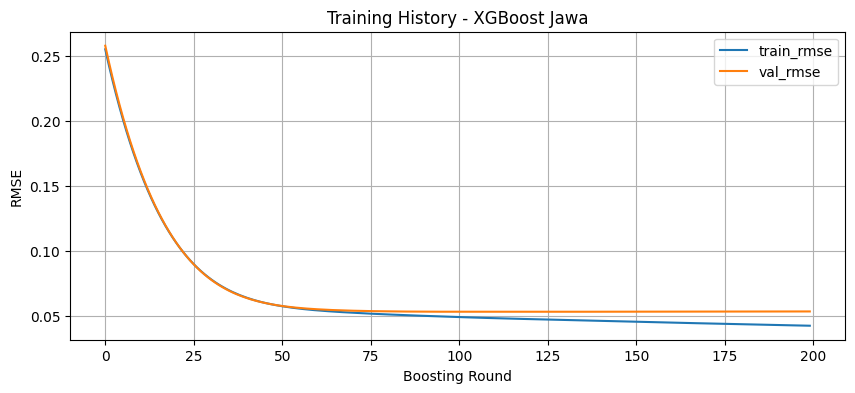

In [8]:
history = jawa_result['history']

plt.figure(figsize=(10, 4))
plt.plot(history['train_rmse'], label='train_rmse')
plt.plot(history['val_rmse'], label='val_rmse')
plt.title('Training History - XGBoost Jawa')
plt.xlabel('Boosting Round')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.show()


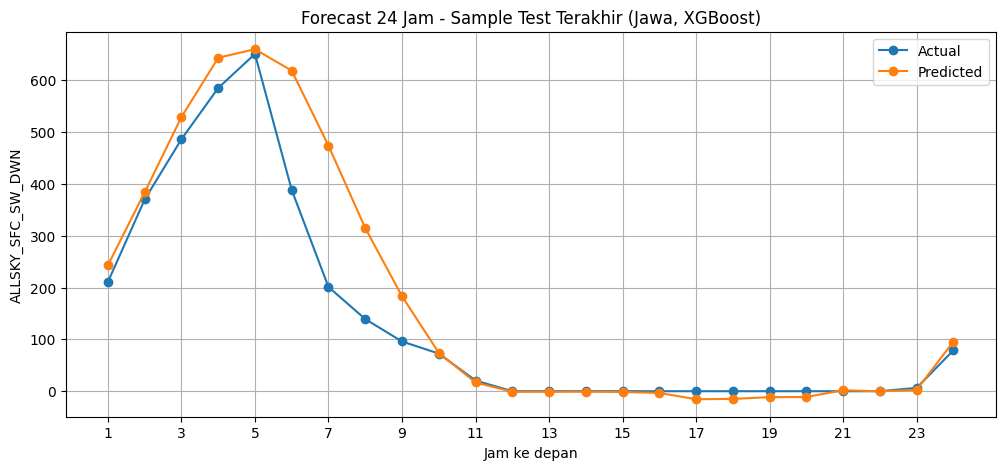

In [9]:
sample_idx = -1
y_true = jawa_result['metrics']['y_true'][sample_idx]
y_pred = jawa_result['metrics']['y_pred'][sample_idx]

plt.figure(figsize=(12, 5))
plt.plot(range(1, HORIZON + 1), y_true, marker='o', label='Actual')
plt.plot(range(1, HORIZON + 1), y_pred, marker='o', label='Predicted')
plt.title('Forecast 24 Jam - Sample Test Terakhir (Jawa, XGBoost)')
plt.xlabel('Jam ke depan')
plt.ylabel(TARGET_COL)
plt.xticks(range(1, HORIZON + 1, 2))
plt.grid(True)
plt.legend()
plt.show()


In [10]:
# Jika nanti ingin training semua pulau, buka komentar pada sel ini.
# all_results = {}
# for region_name in sorted(df_all['REP_NAME'].unique()):
#     print(f'\n=== Training {region_name} ===')
#     all_results[region_name] = train_region_model(df_all, region_name, n_estimators=200, max_depth=6, learning_rate=0.05)
#     print(all_results[region_name]['artifact_paths']['region_dir'].resolve())


In [11]:
def load_region_artifacts(region_name: str):
    region_name = normalize_rep_name(region_name)
    region_dir = OUTPUT_DIR / region_name.replace(' ', '_')
    estimators = joblib.load(region_dir / 'xgboost_models.joblib')
    x_scaler = joblib.load(region_dir / 'x_scaler.joblib')
    y_scaler = joblib.load(region_dir / 'y_scaler.joblib')
    metadata = json.loads((region_dir / 'metadata.json').read_text(encoding='utf-8'))
    return estimators, x_scaler, y_scaler, metadata


def forecast_next_24_hours_from_recent_window(recent_window_df: pd.DataFrame, estimators, x_scaler, y_scaler):
    if len(recent_window_df) != LOOKBACK:
        raise ValueError(f'recent_window_df harus berisi tepat {LOOKBACK} baris.')

    recent_window_df = add_time_features(recent_window_df.copy())
    X_recent = recent_window_df[FEATURE_COLS].values
    X_recent_scaled = x_scaler.transform(X_recent).astype(np.float32)
    X_recent_flat = X_recent_scaled.reshape(1, -1)

    pred_scaled = np.column_stack([estimator.predict(X_recent_flat) for estimator in estimators]).astype(np.float32)
    pred = inverse_transform_targets(pred_scaled, y_scaler)[0]
    return pred


trained_estimators, saved_x_scaler, saved_y_scaler, saved_metadata = load_region_artifacts('Jawa')
recent_window = (
    df_all.loc[df_all['REP_NAME'] == 'Jawa']
    .dropna(subset=BASE_FEATURES + [TARGET_COL])
    .tail(LOOKBACK)
    .copy()
)
forecast_24h = forecast_next_24_hours_from_recent_window(recent_window, trained_estimators, saved_x_scaler, saved_y_scaler)

forecast_df = pd.DataFrame({
    'horizon_hour': np.arange(1, HORIZON + 1),
    'predicted_ALLSKY_SFC_SW_DWN': forecast_24h,
})
forecast_df.head()


,horizon_hour,predicted_ALLSKY_SFC_SW_DWN
0,1,212.463348
1,2,361.571960
2,3,456.911194
3,4,545.414307
4,5,550.379272


## Catatan untuk langkah berikutnya

Untuk integrasi Open-Meteo nanti:
- isi `rep_name_coordinates_template.json` dengan koordinat titik representatif final per `REP_NAME`
- ambil data cuaca dari koordinat tersebut
- bentuk 24 baris input terbaru sesuai `FEATURE_COLS`
- panggil `forecast_next_24_hours_from_recent_window(...)`

Karena XGBoost saat ini menang pada eksperimen `Jawa`, notebook ini cocok dipakai sebagai baseline produksi awal sebelum melakukan tuning lanjutan atau ekspansi ke semua pulau.